In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv('dataset.csv')
print('Shape:', data.shape)
data.head()

Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print('Missing values:', data.isnull().sum().sum())
print('Duplicates:', data.duplicated().sum())

Missing values: 0
Duplicates: 0


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


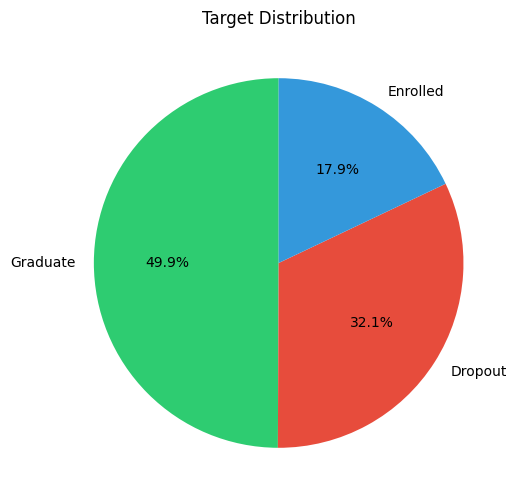

In [4]:
print(data['Target'].value_counts())

counts = data['Target'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#e74c3c','#3498db'], startangle=90)
plt.title('Target Distribution')
plt.show()

In [5]:
for col in ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    data = data[(data[col] >= Q1 - 3*IQR) & (data[col] <= Q3 + 3*IQR)]

print('Shape after outlier removal:', data.shape)

Shape after outlier removal: (3512, 35)


In [6]:
le = LabelEncoder()
data['Target'] = le.fit_transform(data['Target'])

cat_cols = [c for c in data.columns if data[c].dtype == 'int64' and c != 'Target']
p_values = pd.Series(chi2(data[cat_cols], data['Target'])[1], index=cat_cols)

cols_to_drop = p_values[p_values >= 0.05].index.tolist()
data.drop(columns=cols_to_drop, inplace=True)
print('Dropped:', cols_to_drop)
print('Shape after feature selection:', data.shape)

Dropped: ['Marital status', 'Daytime/evening attendance', 'Nacionality', 'Educational special needs', 'International']
Shape after feature selection: (3512, 30)


In [7]:
# ── Data Split ──
X = data.drop('Target', axis=1)
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (2809, 29) | Test: (703, 29)


In [8]:
# ── Data Scaling ──
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Scaling done.')

Scaling done.


=== Decision Tree ===
Accuracy : 0.6401
Precision: 0.6390
Recall   : 0.6401
              precision    recall  f1-score   support

     Dropout       0.47      0.47      0.47       134
    Enrolled       0.41      0.40      0.41       142
    Graduate       0.77      0.77      0.77       427

    accuracy                           0.64       703
   macro avg       0.55      0.55      0.55       703
weighted avg       0.64      0.64      0.64       703



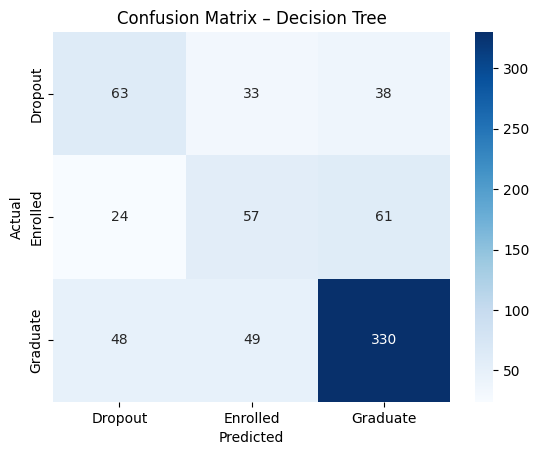

In [9]:
# ── Algorithm 1: Decision Tree ──
dt = DecisionTreeClassifier(random_state=23)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_acc  = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt, average='weighted')
dt_rec  = recall_score(y_test, y_pred_dt, average='weighted')

print('=== Decision Tree ===')
print(f'Accuracy : {dt_acc:.4f}')
print(f'Precision: {dt_prec:.4f}')
print(f'Recall   : {dt_rec:.4f}')
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Decision Tree')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

=== Random Forest ===
Accuracy : 0.7454
Precision: 0.7346
Recall   : 0.7454
              precision    recall  f1-score   support

     Dropout       0.76      0.47      0.58       134
    Enrolled       0.55      0.45      0.50       142
    Graduate       0.79      0.93      0.85       427

    accuracy                           0.75       703
   macro avg       0.70      0.62      0.64       703
weighted avg       0.73      0.75      0.73       703



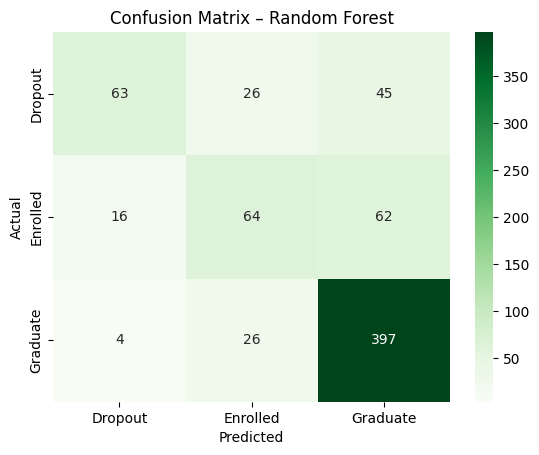

In [10]:
# ── Algorithm 2: Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=23)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='weighted')
rf_rec  = recall_score(y_test, y_pred_rf, average='weighted')

print('=== Random Forest ===')
print(f'Accuracy : {rf_acc:.4f}')
print(f'Precision: {rf_prec:.4f}')
print(f'Recall   : {rf_rec:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – Random Forest')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

=== KNN (K=5) ===
Accuracy : 0.6913
Precision: 0.6660
Recall   : 0.6913
              precision    recall  f1-score   support

     Dropout       0.64      0.46      0.53       134
    Enrolled       0.41      0.30      0.35       142
    Graduate       0.76      0.89      0.82       427

    accuracy                           0.69       703
   macro avg       0.60      0.55      0.57       703
weighted avg       0.67      0.69      0.67       703



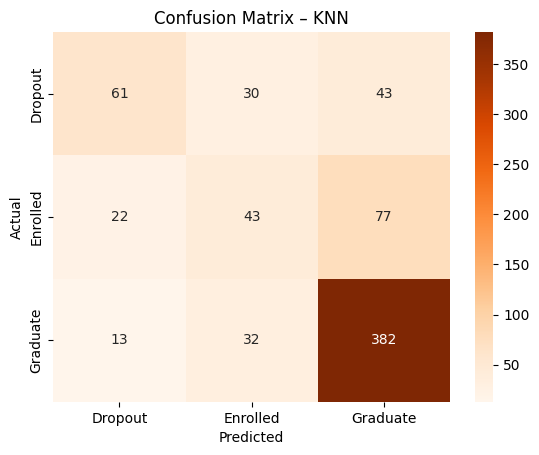

In [11]:
# ── Algorithm 3: KNN ──
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

knn_acc  = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn, average='weighted')
knn_rec  = recall_score(y_test, y_pred_knn, average='weighted')

print('=== KNN (K=5) ===')
print(f'Accuracy : {knn_acc:.4f}')
print(f'Precision: {knn_prec:.4f}')
print(f'Recall   : {knn_rec:.4f}')
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – KNN')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

    Algorithm  Accuracy  Precision   Recall
Random Forest  0.745377   0.734570 0.745377
          KNN  0.691323   0.666041 0.691323
Decision Tree  0.640114   0.639012 0.640114


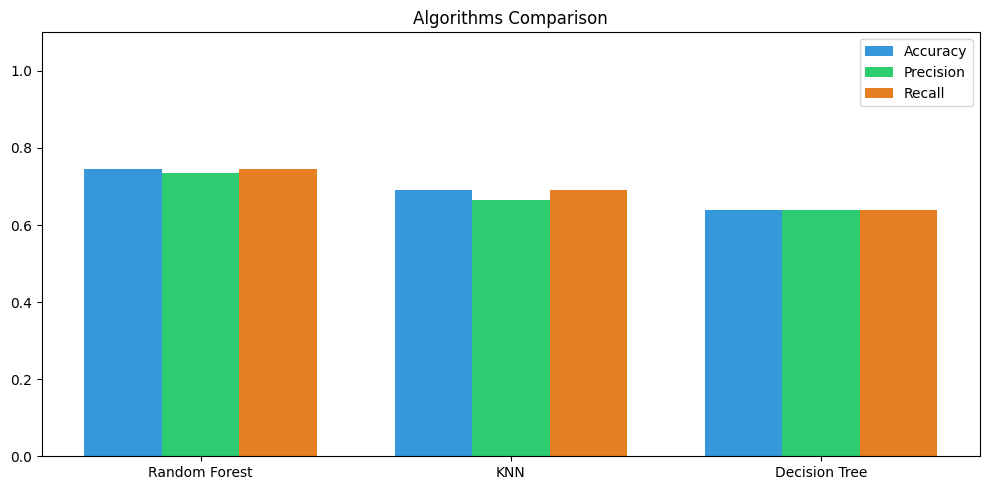

In [12]:
# ── Conclusion: Comparison ──
results = pd.DataFrame({
    'Algorithm': ['Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy' : [dt_acc,  rf_acc,  knn_acc],
    'Precision': [dt_prec, rf_prec, knn_prec],
    'Recall'   : [dt_rec,  rf_rec,  knn_rec]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

x = np.arange(3)
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, results['Accuracy'],  w, label='Accuracy',  color='#3498db')
ax.bar(x,     results['Precision'], w, label='Precision', color='#2ecc71')
ax.bar(x + w, results['Recall'],    w, label='Recall',    color='#e67e22')
ax.set_xticks(x)
ax.set_xticklabels(results['Algorithm'])
ax.set_ylim(0, 1.1)
ax.set_title('Algorithms Comparison')
ax.legend()
plt.tight_layout()
plt.show()